# OpenFAST Session 2

The topic of this second session with OpenFAST will be to start using OpenFAST for wind generation and aerodynamic modelling. We will explore the input files for the turbine blades, the various aerodynamic conditions and the available outputs. 

Because we work with python, we will start by importing the openfast toolbox library. 

In [3]:
import sys 
import os 
script_dir = os.getcwd()
sys.path.append(script_dir + "/../openfast_toolbox_local")
from openfast_toolbox.io import FASTInputFile, TurbSimFile, FASTOutputFile   
from openfast_toolbox.case_generation import runner 

import matplotlib.pyplot as plt 
import numpy as np 


## 1st Part: Input wind 

Before we compute aerodynamic loads, we need to investigate how we can generate some wind. In OpenFAST, wind generation is done in the InflowWind module. We will see 3 types of wind generation. For now, we only want to study the wind generation, so we will set all ElastoDyn DoF to False in order to have a purely rigid wind turbine. 

We will use the _SWRT_021.fst_ file with the _SWRT_ED_rigid.dat_ elastodyn file. 

### Question 1

Run a dummy simulation with a steady wind inflow which as a value of 12 mps at the SWRT hub height. Plot the horizontal wind speed in the first 100 meters of the atmospheric boundary layer.

_Hints_ : You need to use InflowWind windtype = 1 and set some output at various heights in InflowWind. 

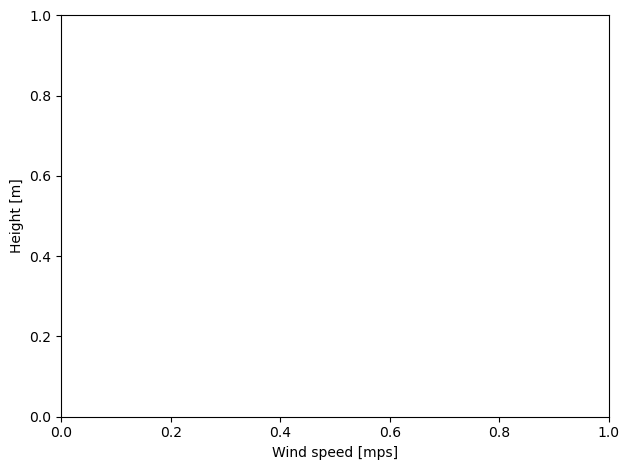

In [4]:
#
# Load your simulation data
#

fig, axs = plt.subplots(1,1)
ax = axs

#
#Display the right values
#

ax.set_xlabel('Wind speed [mps]')
ax.set_ylabel('Height [m]')
plt.tight_layout()
plt.show()

## Question 2 

Run a dummy simulation with a stepped wind with the values 8 mps between 0 and 30 seconds, 10 mps between 30 and 60 seconds and 12 mps between 60 and 90 seconds 

_Hint:_ you can use InflowWind wintype = 2 and the rampWind.dat template file

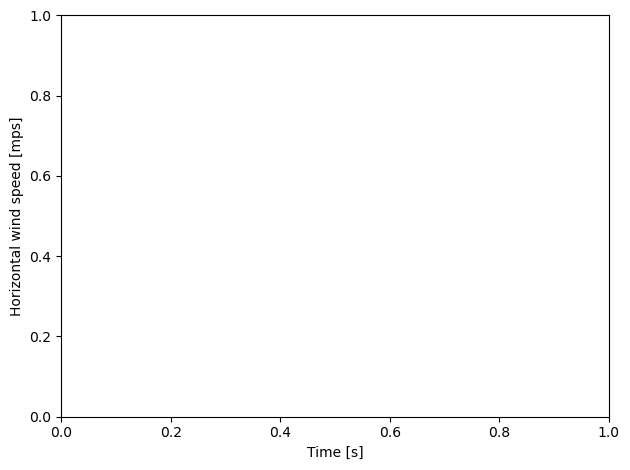

In [5]:
#
# Load your simulation data
#

fig, axs = plt.subplots(1,1)
ax = axs

#
#Display the right values
#

ax.set_xlabel('Time [s]')
ax.set_ylabel('Horizontal wind speed [mps]')
plt.tight_layout()
plt.show()

Simple homogeneous and steady wind are good to showcase some of the turbine behaviour and parameters. If we want to run a realistic simulation, we will need a more realistic wind input. We can use a turbulent full field, it is a 2D grid depicting the local velocities of the wind on the full rotor disk. InflowWind does not have an integrated engine for turbulent wind generation, but NREL provides us with a tool to do just that: the TurbSim software. Its use is the same as OpenFAST, we need to set up an input file and then we can call the software and the input file to generate a wind field for us. 

To run TurbSim, you can use the _turb12mps.inp_ input file for TurbSim

## Question 3 

What does the following variable represent in TurbSim ? 

__NumGrid_Z__

__HubHt__

__PLExp__

## Answer 3


Now we can run turbsim, if you have the turbsim executable in your folder, you can run the following command : 

<code>
..\..\executables\turbsim_x64.exe turb12mps.inp 
</code>

## Question 4 

Run a turbsim simulation with a mean wind speed of 13 mps and display yhe (y,z) wind plane. If it goes well the output should be a .bts file which contains the full field information at each time step. Display your field at time t = 10 s and compute the mean wind speed value at this time. 




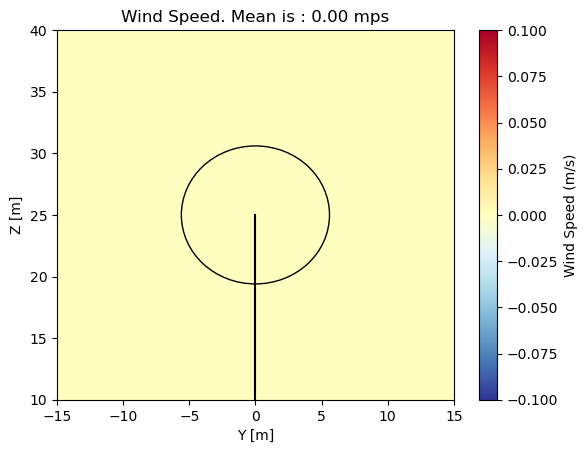

In [9]:
TSFile = "." #your .bts file 

t = 20 #seconds 
yMin = -15
yMax = 15 
zMin = 10
zMax = 40
if TSFile == "." :
    plane10s = np.zeros((100,100))
else : 
    TS = TurbSimFile(TSFile)
    plane10s = TS['u'][0,int(t/TS.dt),:,:]

fig, ax = plt.subplots()
meanWindSpeed = np.mean(plane10s)
im = ax.imshow(plane10s.T, cmap='RdYlBu_r', interpolation='spline16', extent=[yMin, yMax, zMax, zMin], aspect='auto')
plt.colorbar(im, ax=ax, label='Wind Speed (m/s)')
ax.set_title(f'Wind Speed. Mean is : {meanWindSpeed:02.2f} mps')
ax.set_xlabel('Y [m]')
ax.set_ylabel('Z [m]')
ax.invert_yaxis()
circle = plt.Circle((0, 25), 5.6, color='black', fill=False)
ax.plot([0, 0], [10, 25], color='black')
ax.add_patch(circle)
plt.show()

We have seen various ways to generate inflow wind for our wind turbine simulation. Now we are ready to compute some aerodynamic loads on the turbine. 

## 2nd Section

We will now look at the input files for Aerodyn. In the first practical, when using Elastodyn, we have set some mechanical properties for the blade. For Aerodyn we need to specify their aerodynamic properties.

The AeroDyn file holds a section for the aerodynamic description of the blade. 

## Question 5 
Explore the AeroDyn configuration file and answer to the following: 

__How many sections are used to describe the blade ?__ 

__How many different airfoil are used ?__ 

__What is the maximum chord of the blade ?__ 


## Answer 5 

We will launch a simulation with a ramped wind. Using the SWRT_022.fst file, we will set up a simulation with a ramped wind from 10 to 16 mps over 300s. We want to display the total aerodynamic torque on the rotor, the total aerodynamic thrust and the rotor aerodyanmic power. 


## Question 6 

Run this simulation and plot the three required time series. 


In [10]:
outFilePath = "SWRT_02/SWRT_022.out"
df = FASTOutputFile(outFilePath).toDataFrame()

# We will clean up the column names and store the units in a dictionary
colNames = df.columns 
renameDict = {}
unitsDict = {}
for colName in colNames : 
    name,unit = colName.split("_")
    unit = unit.strip('[]')
    renameDict[colName] = name 
    unitsDict[name] = unit 
df = df.rename(columns=renameDict)

# Specify here the columns that you want to plot 
columns = []
colors = ['blue','red','green','orange']


for i,col in enumerate(columns): 
    fig,axs = plt.subplots(1,squeeze=False)
    axs = axs.flatten()
    ax = axs[0]
    ax.plot(df['Time'],df[col],color=colors[i],label=col)
    ax.plot(df['Time'],df['Wind1VelX'],color='pink')
    ax.set_xlabel(f"Time ({unitsDict['Time']})")
    ax.set_ylabel(f"{col} ({unitsDict[col]})")
    ax.set_title(f"Time series for {col} [{unitsDict[col]}]")
    ax.grid()


In order to have some information about the power on the generator, we have set a simple generator model using Servodyn. 

## Question 7 

Compare the power generated on the drivetrain with the aerodynamic power available for 10, 14 and 18 mps. Display the values on a graph and comment your results. 

_Hint_ you can do it with a single simulation using some step wind. 

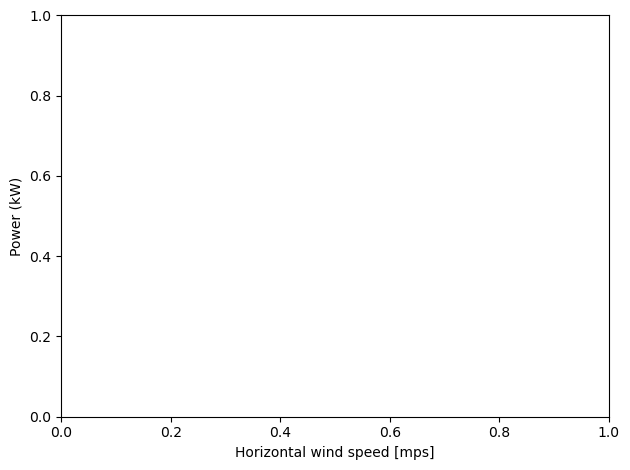

In [11]:
#
# Load your simulation data
#

fig, axs = plt.subplots(1,1)
ax = axs

#
#Display the right values
#

ax.set_ylabel('Power (kW)')
ax.set_xlabel('Horizontal wind speed [mps]')
plt.tight_layout()
plt.show()



## Answer 7  

Another thing AeroDyn enables us to do is to output the aerodynamic loads on each section of the blade. This can be done using the nodal input section. We will use it to understand the control mechanism on this turbine. 

It has no active control, which means only the natural pitching of the blade will allow for some power limitation. After a given rotational spin, the tip of the turbine will start stalling, and the faster it spins the closer the stalling point will get to the hub. 

## Question 8 

Display the lift and drag forces on the blade at wind speed 10, 14 and 18 mps. Then display the forces normal and tangential to the rotor disk plane. 



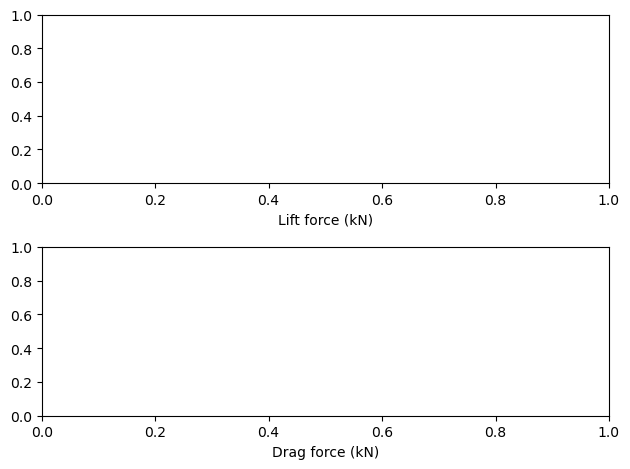

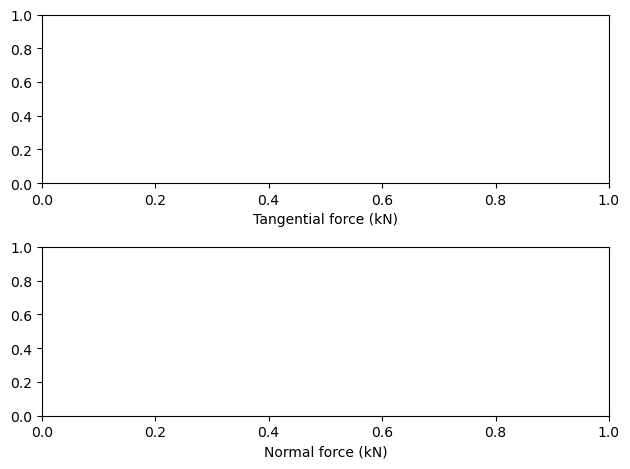

In [12]:
#
# Load your simulation data
#

fig, axs = plt.subplots(2,1)

#
#Display the right values
#

ax = axs[0]
ax.set_xlabel('Blade Node')
ax.set_xlabel('Lift force (kN)')
ax = axs[1]
ax.set_xlabel('Blade Node')
ax.set_xlabel('Drag force (kN)')
plt.tight_layout()
plt.show()

#
# Load your simulation data
#

fig, axs = plt.subplots(2,1)

#
#Display the right values
#

ax = axs[0]
ax.set_xlabel('Blade Node')
ax.set_xlabel('Tangential force (kN)')
ax = axs[1]
ax.set_xlabel('Blade Node')
ax.set_xlabel('Normal force (kN)')
plt.tight_layout()
plt.show()

## Problem 

What is the maximum bending moment (edgewise and flapwise) that the blade will undergo in a 13 mps turbulent wind ? At which section ? 